Importer les dépendances

In [ ]:
import pandas as pd
import cv2
import numpy as np
import pickle
import os
import random
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms        # Pour balancer les données si on a le temps
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, ConcatDataset
from torch.utils.data import DataLoader
from torch.utils.data.sampler import (SubsetRandomSampler,
                                      RandomSampler)

import matplotlib.pyplot as plt
%matplotlib inline

print(f"Your version of Pytorch is {torch.__version__}.")


Your version of Pytorch is 2.9.0+cu126.


Charger et Explorer les données

------------Analyse data d'entraînement:-------------
Nombre total d'image: 1080
Images shape: (1080, 28, 28, 3)
Labels shape: (1080, 1)
Lables type:  <class 'numpy.ndarray'>
Missing values in images: 0
Missing values in labels: 0
Min label: 0
Max label: 4
Class 0: 486
Class 1: 128
Class 2: 206
Class 3: 194
Class 4: 66

----------------L'importance de chaque canal----------------
Canal Rouge:
  Min: 0, Max: 255
  Moyenne: 53.59, Écart-type: 48.29
Canal Vert:
  Min: 0, Max: 75
  Moyenne: 1.36, Écart-type: 4.25
Canal Bleu:
  Min: 0, Max: 184
  Moyenne: 58.28, Écart-type: 43.30

---------------- Importance des canaux par CLASSE ----------------

=== Classe 0 ===
  Canal Rouge:
    Min: 0.00, Max: 255.00
    Moyenne: 63.58
    Écart-type: 53.19
  Canal Vert:
    Min: 0.00, Max: 67.00
    Moyenne: 1.85
    Écart-type: 4.70
  Canal Bleu:
    Min: 0.00, Max: 184.00
    Moyenne: 64.59
    Écart-type: 44.88

=== Classe 1 ===
  Canal Rouge:
    Min: 0.00, Max: 255.00
    Moyenne: 47.47
    Écart

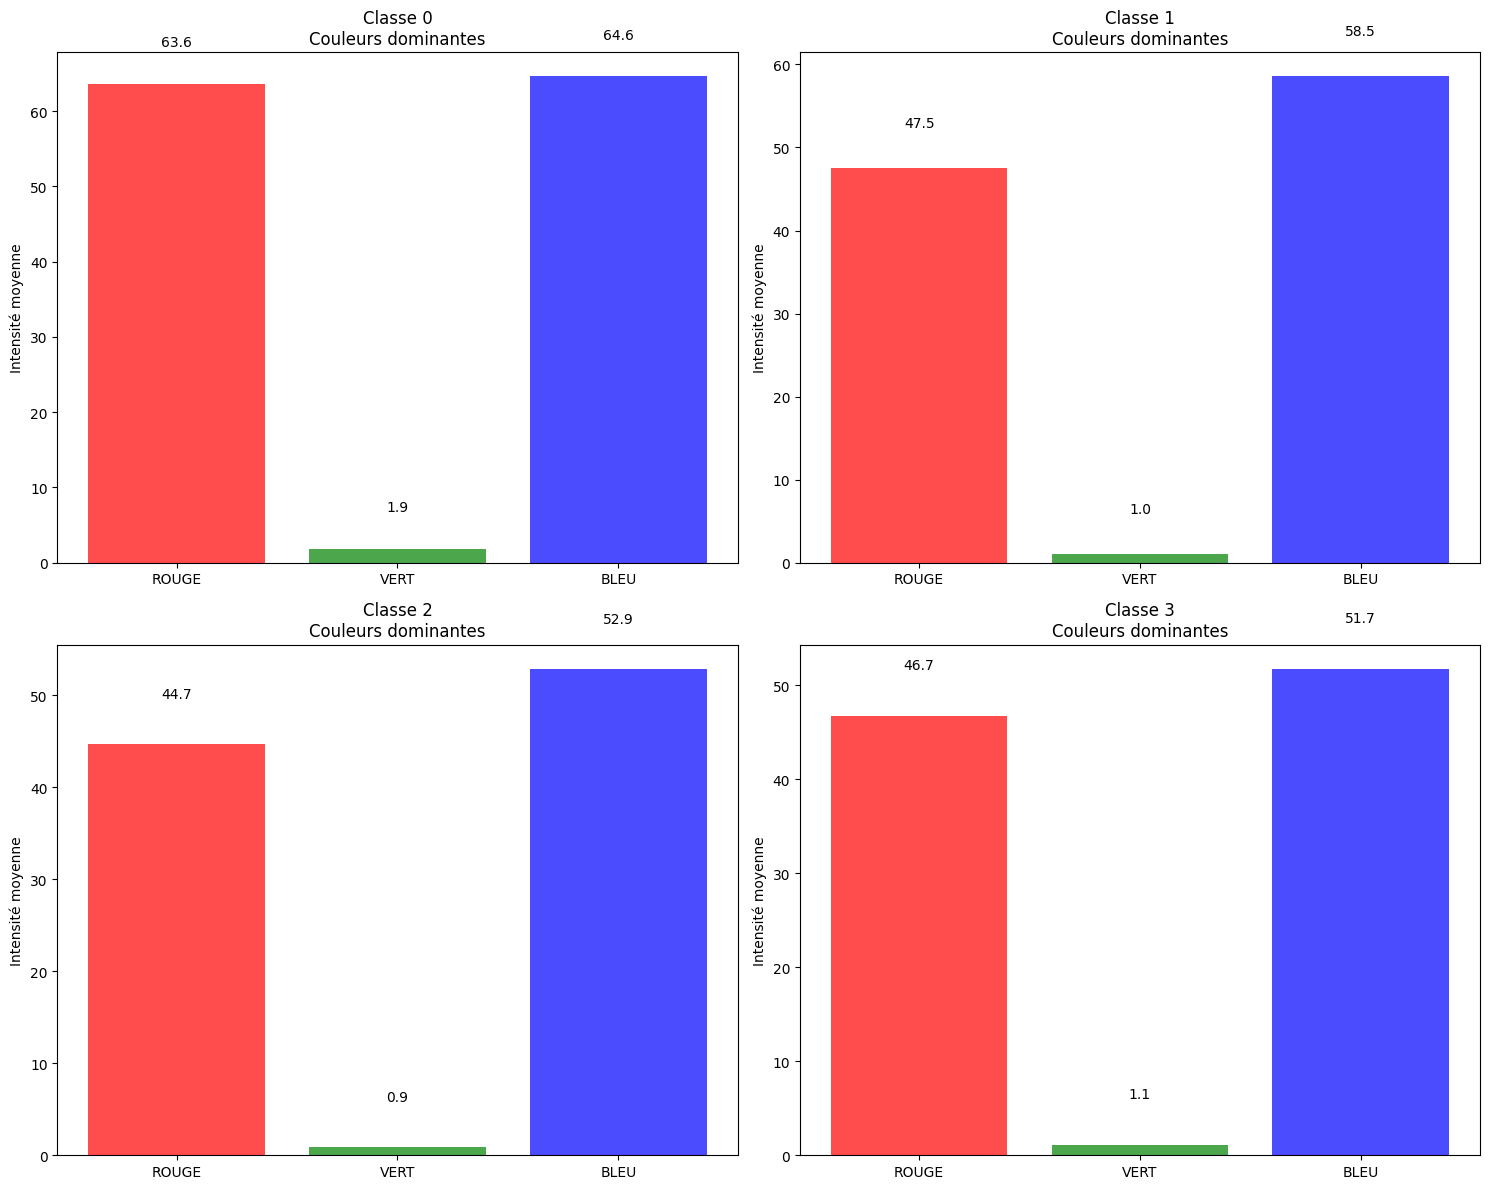


-------------Histogramme valeurs pixels-------------


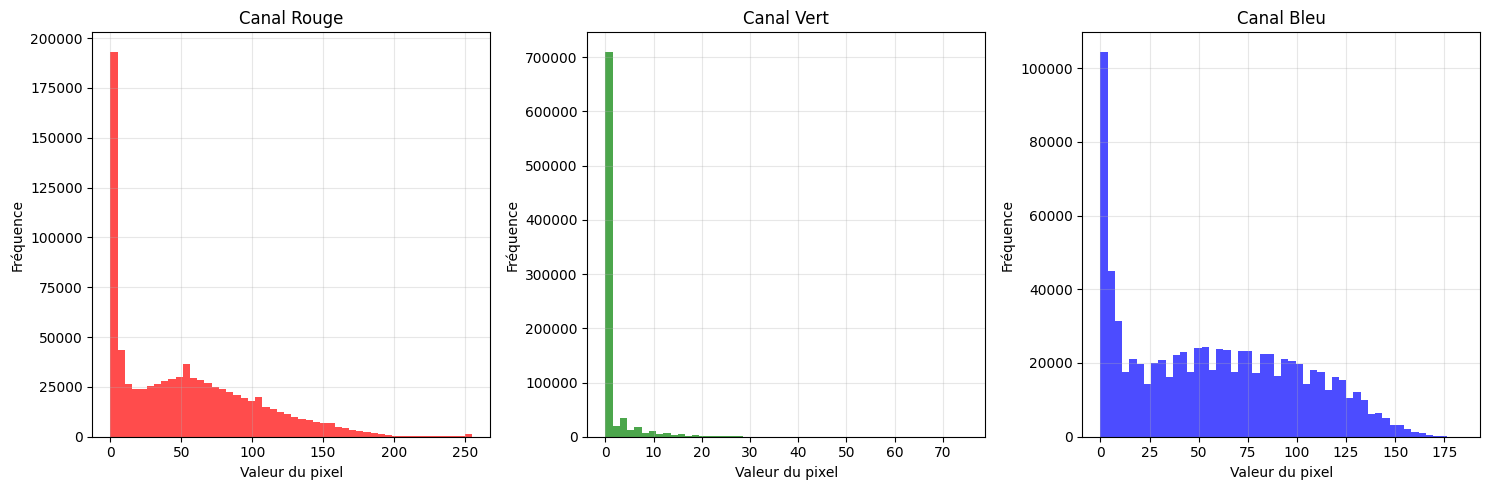


---------------Luminosité des images---------------
Nombre d'images analysées: 1080
Luminosité moyenne: 37.7
Luminosité min: 9.1
Luminosité max: 83.8


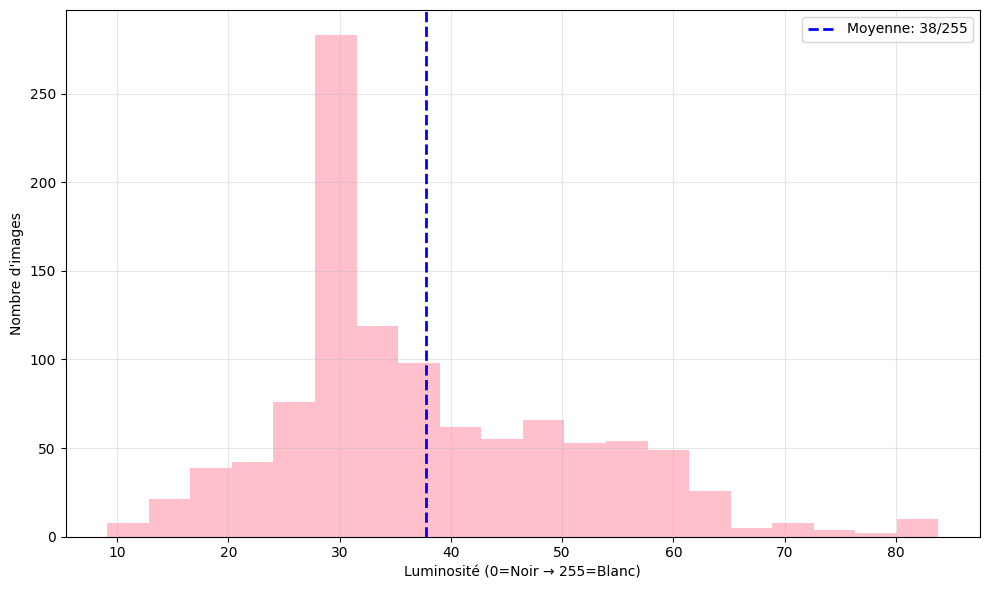

In [ ]:
# Load the pickle file
with open('train_data.pkl', 'rb') as f:
    train_data = pickle.load(f)

# Access images and labels
images = train_data['images']
labels = train_data['labels']

print("------------Analyse data d'entraînement:-------------")

# Print images and labels shapes
print(f"Nombre total d'image: {len(images)}")
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
# Print labels type
print("Lables type: ", type(labels[0]))
# Print missing values
print("Missing values in images:", np.isnan(images).sum().sum())
print("Missing values in labels:", np.isnan(labels).sum())

# Every label is a 1 dimension array
print("Min label:", labels.min())
print("Max label:", labels.max())

# Print labels repartition
classes, counts = np.unique(labels, return_counts=True)
for c, n in zip(classes, counts):
    print(f"Class {c}: {n}")

# Analyser les statistiques des 3 couleurs des canaux
print(f"\n----------------L'importance de chaque canal----------------")
channels = ['Rouge', 'Vert', 'Bleu']

for i, channel in enumerate(channels):
    channel_data = images[:, :, :, i]
    print(f"Canal {channel}:")
    print(f"  Min: {channel_data.min()}, Max: {channel_data.max()}")
    print(f"  Moyenne: {channel_data.mean():.2f}, Écart-type: {channel_data.std():.2f}")


unique_labels = np.unique(labels)
channels = ['Rouge', 'Vert', 'Bleu']

print("\n---------------- Importance des canaux par CLASSE ----------------")

for class_label in unique_labels:
    print(f"\n=== Classe {class_label} ===")

    # Extraire les images de cette classe
    class_indices = np.where(labels == class_label)[0]
    class_images = images[class_indices]

    for i, channel in enumerate(channels):
        channel_data = class_images[:, :, :, i]

        print(f"  Canal {channel}:")
        print(f"    Min: {channel_data.min():.2f}, Max: {channel_data.max():.2f}")
        print(f"    Moyenne: {channel_data.mean():.2f}")
        print(f"    Écart-type: {channel_data.std():.2f}")


##################################################################### À ENLEVER

# Exemple: différentes classes peuvent avoir des couleurs dominantes différentes
unique_labels = np.unique(labels)

# Calculer les couleurs moyennes par classe
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

colors = ['red', 'green', 'blue']
color_names = ['ROUGE', 'VERT', 'BLEU']

for i, class_label in enumerate(unique_labels[:4]):  # Prendre max 4 classes
    class_indices = np.where(labels == class_label)[0]
    class_images = images[class_indices]

    # Calculer la couleur moyenne pour cette classe
    mean_red = np.mean(class_images[:, :, :, 0])
    mean_green = np.mean(class_images[:, :, :, 1])
    mean_blue = np.mean(class_images[:, :, :, 2])

    means = [mean_red, mean_green, mean_blue]

    # Afficher le graphique des couleurs dominantes
    bars = axes[i//2, i%2].bar(color_names, means, color=colors, alpha=0.7)
    axes[i//2, i%2].set_title(f'Classe {class_label}\nCouleurs dominantes')
    axes[i//2, i%2].set_ylabel('Intensité moyenne')

    # Ajouter les valeurs
    for bar, mean_val in zip(bars, means):
        axes[i//2, i%2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                            f'{mean_val:.1f}', ha='center')

plt.tight_layout()
plt.show()

print(f"\n-------------Histogramme valeurs pixels-------------")
# Visualiser les histogrammes des pixels
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
channels = ['Rouge', 'Vert', 'Bleu']
colors = ['red', 'green', 'blue']

for i, (channel, color) in enumerate(zip(channels, colors)):
    channel_data = images[:, :, :, i].flatten()
    axes[i].hist(channel_data, bins=50, color=color, alpha=0.7)
    axes[i].set_title(f'Canal {channel}')
    axes[i].set_xlabel('Valeur du pixel')
    axes[i].set_ylabel('Fréquence')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()
###############################################################################

print(f"\n---------------Luminosité des images---------------")
luminosites = []
for img in images:
    # Moyenne des 3 canaux = luminosité
    gris = np.mean(img, axis=2)
    luminosite_moyenne = np.mean(gris)
    luminosites.append(luminosite_moyenne)

luminosites = np.array(luminosites)

print(f"Nombre d'images analysées: {len(luminosites)}")
print(f"Luminosité moyenne: {np.mean(luminosites):.1f}")
print(f"Luminosité min: {np.min(luminosites):.1f}")
print(f"Luminosité max: {np.max(luminosites):.1f}")

##################################################################### À ENLEVER
# Histogramme de luminosité
plt.figure(figsize=(10, 6))

# Toutes les barres en bleu
plt.hist(luminosites, bins=20, color='pink')

plt.xlabel('Luminosité (0=Noir → 255=Blanc)')
plt.ylabel('Nombre d\'images')
plt.grid(True, alpha=0.3)

moyenne = np.mean(luminosites)
# Ligne pour la moyenne
plt.axvline(moyenne, color='blue', linestyle='--', linewidth=2,
           label=f'Moyenne: {moyenne:.0f}/255')
plt.legend()

plt.tight_layout()
plt.show()
###############################################################################

Prétraitement des données

In [ ]:
# GRAYSCALE
"""def data_processor(images):
    # 1. Copie et conversion en float32
    X_processed = images.copy().astype("float32")

    # 2. Conversion en Niveaux de Gris (Luminosité)
    # On utilise la formule standard de luminosité pour le calcul
    # Luminosité (Y) = 0.2989 * R + 0.5870 * G + 0.1140 * B
    # On utilise np.dot pour effectuer la somme pondérée sur le dernier axe (canaux)
    # Le résultat est un tensor de forme [N, H, W]
    X_grayscale = np.dot(X_processed[..., :3], [0.2989, 0.5870, 0.1140])

    # Ajouter l'axe du canal (maintenant 1 canal) : [N, H, W] -> [N, H, W, 1]
    X_processed = np.expand_dims(X_grayscale, axis=-1)

    # 3. Normalisation [0, 255] -> [0, 1]
    X_processed = X_processed / 255.0

    # 4. Standardisation (sur l'ensemble des pixels du canal unique)
    # Calcul de la moyenne et de l'écart type sur tous les pixels de toutes les images
    mean = X_processed.mean(axis=(0, 1, 2))
    std = X_processed.std(axis=(0, 1, 2)) + 1e-8
    X_processed = (X_processed - mean) / std

    # 5. Transposer pour PyTorch: [N, H, W, C] → [N, C, H, W]
    X_processed = np.transpose(X_processed, (0, 3, 1, 2))

    return X_processed"""

# COULEURS
"""def data_processor(images):
    n_images = images.shape[0]

    X_processed = images.copy().astype("float32")

    # On normalise les caractéristiques [0, 255]->[0, 1]
    X_processed = X_processed / 255.0

    # Standardiser chaque canal couleur séparément
    for canal in range(3):  # R, G, B
      canal_data = X_processed[:, :, :, canal]

      # Normalisation canal par canal
      mean = canal_data.mean(axis=0)
      std = canal_data.std(axis=0) + 1e-8
      canal_data = (canal_data - mean) / std

      X_processed[:, :, :, canal] = canal_data

    # Transposer pour PyTorch: [N, H, W, C] → [N, C, H, W]
    X_processed = np.transpose(X_processed, (0, 3, 1, 2))

    return X_processed"""

# CONTRASTE
def data_processor(images):
    X_processed = images.copy().astype("float32")
    n_images, h, w, c = X_processed.shape

    # --- 1. AMÉLIORATION DU CONTRASTE (CLAHE) ---
    # Cette étape doit se faire sur les valeurs brutes [0, 255]

    # Création de l'objet CLAHE une seule fois
    # Clip limit: Limite l'amplification du contraste pour éviter le bruit
    # Tile Grid Size: Taille de la grille sur laquelle l'égalisation est appliquée
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    X_contrast_enhanced = np.zeros_like(X_processed)

    for i in range(n_images):
        img_rgb = X_processed[i].astype(np.uint8) # CLAHE fonctionne sur uint8

        # conversion de RGB à LAB (plus robuste pour le contraste que HSV)
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

        # séparation des canaux LAB : L (Luminosité), A, B (Couleur)
        l, a, b = cv2.split(img_lab)

        # application du CLAHE uniquement au canal de Luminosité (L)
        l_contrast = clahe.apply(l)

        # fusion des canaux et retour à RGB
        img_lab_enhanced = cv2.merge((l_contrast, a, b))
        img_rgb_enhanced = cv2.cvtColor(img_lab_enhanced, cv2.COLOR_LAB2RGB)

        X_contrast_enhanced[i] = img_rgb_enhanced

    X_processed = X_contrast_enhanced

    # Normalisation [0, 255] -> [0, 1]
    X_processed = X_processed / 255.0

    # Standardiser chaque canal couleur séparément
    for canal in range(3):  # R, G, B
        canal_data = X_processed[:, :, :, canal]

        # Normalisation canal par canal
        # mean et std sont calculés sur le lot (axis=0) et les dimensions spatiales (axis=1, 2)
        mean = canal_data.mean(axis=(0, 1))
        std = canal_data.std(axis=(0, 1)) + 1e-8
        canal_data = (canal_data - mean) / std

        X_processed[:, :, :, canal] = canal_data

    # Transposer pour PyTorch: [N, H, W, C] → [N, C, H, W]
    X_processed = np.transpose(X_processed, (0, 3, 1, 2))

    return X_processed



# Les deux versions
# flat_images_gris = data_processor_gris(images)  # Version originale (gris)
processed_images = data_processor(images)  # Nouvelle version (couleur)

# On sort les labels de leur array
int_labels = labels.reshape(-1)

# print(f"Version gris: {flat_images_gris.shape}")
print(f"Forme des données prétraitées: {processed_images.shape}")

Forme des données prétraitées: (1080, 3, 28, 28)


Préparer les données d'entraînement et de validation

In [ ]:
"""np.random.seed(0)
indices = np.random.permutation(len(labels))
X_train = flat_images_couleur[indices[:900]]
X_valid = flat_images_couleur[indices[900:]]
y_train = int_labels[indices[:900]]
y_valid = int_labels[indices[900:]]"""
(X_train, X_valid, y_train, y_valid) = train_test_split(processed_images, int_labels)

print("X_TRAIN SHAPE: ", X_train.shape)
print("Y_TRAIN SHAPE: ", y_train.shape)
print(y_train)
print("Labels min:", y_train.min())
print("Labels max:", y_train.max())
print("Unique labels:", np.unique(y_train)[:20])

X_TRAIN SHAPE:  (810, 3, 28, 28)
Y_TRAIN SHAPE:  (810,)
[0 1 3 0 2 2 1 3 0 3 3 0 0 3 2 0 0 3 0 4 0 0 3 0 1 1 0 2 1 1 0 0 0 0 3 0 2
 4 2 4 0 0 3 0 2 4 2 0 0 3 0 0 0 0 0 2 1 3 2 0 0 0 3 4 3 0 0 0 0 0 2 2 0 0
 0 0 3 1 3 0 3 0 0 2 0 0 1 2 0 0 2 2 2 0 2 0 0 0 2 1 3 4 0 1 0 1 1 1 1 0 0
 0 0 2 4 1 2 0 0 3 0 0 0 0 0 0 0 3 3 2 1 2 2 0 1 0 0 0 3 1 3 3 1 1 0 0 0 1
 0 0 0 0 1 0 3 0 0 2 0 0 4 3 3 3 1 0 0 3 3 2 0 0 0 4 2 0 0 3 3 2 2 3 1 2 2
 0 0 0 2 3 0 0 4 1 0 3 2 1 0 3 0 2 0 0 0 1 0 0 0 4 3 0 3 0 0 0 0 0 0 2 1 0
 0 0 2 0 2 3 3 2 0 4 0 2 3 0 4 3 1 3 0 0 2 0 1 0 3 1 0 0 0 0 0 0 0 3 0 4 2
 3 1 3 3 0 0 0 0 3 3 3 4 0 4 0 2 0 0 1 0 0 0 0 0 1 1 3 0 0 2 0 0 4 1 1 3 1
 4 3 1 0 2 2 0 4 4 0 0 0 2 0 1 0 3 0 2 0 1 3 0 0 2 0 0 2 0 0 2 1 0 3 0 3 0
 0 0 2 0 3 0 3 3 1 1 3 2 2 0 3 4 3 0 4 0 1 3 0 1 2 0 1 4 0 2 3 0 0 2 0 0 4
 1 2 2 2 3 0 2 0 0 0 0 0 3 3 4 0 0 0 2 2 3 3 2 1 2 3 4 0 0 0 3 0 0 0 0 0 0
 0 0 1 0 0 4 3 2 3 0 4 2 3 0 4 3 3 0 0 3 4 1 3 0 0 0 1 4 1 0 0 3 3 0 1 0 1
 0 0 1 0 2 0 1 3 0 3 0 0 1 1 0 0 0 1 3 1 2 0

Utilisation du GPU si disponible

In [ ]:

if torch.cuda.is_available():
    device = torch.device("cuda")
    use_cuda = True
else:
    device = torch.device("cpu")
    use_cuda = False

Création de dataset tensor


In [ ]:
# On importe déjà nos données test
with open('test_data.pkl', 'rb') as f:
    test_data = pickle.load(f)

test_images = test_data['images']
X_test = data_processor(test_images)

# Transformation de nos données en tensor
X_train_tensor = torch.from_numpy(X_train).float().to(device)
X_valid_tensor = torch.from_numpy(X_valid).float().to(device)
X_test_tensor = torch.from_numpy(X_test).float().to(device)
y_train_tensor = torch.from_numpy(y_train).long().to(device)
y_valid_tensor = torch.from_numpy(y_valid).long().to(device)

# Construction de nos tensorDataset
original_train_data = TensorDataset(X_train_tensor, y_train_tensor)
valid_data = TensorDataset(X_valid_tensor, y_valid_tensor)
test_data = TensorDataset(X_test_tensor)   # y à prédire

# num_classes = train_data['label'].num_classes
# print(num_classes)

Augmentation et balancement des données d'entraînement


In [ ]:
from PIL import Image
import torchvision.transforms as T
import math

SEED_VALUE = 42
np.random.seed(SEED_VALUE)
random.seed(SEED_VALUE)
torch.manual_seed(SEED_VALUE)

print("ORIGINAL CLASS COUNT")
classes, counts = np.unique(y_train, return_counts=True)
for c, n in zip(classes, counts):
    print(f"Class {c}: {n}")

class_counts = {0: 361, 1: 95, 2: 165, 3: 142, 4: 47}
# On veut doubler la classe 1 et avoir environ le même nombre de données/classe
target_count = max(class_counts.values())*10    # On veut 10x plus de données

# Facteur d'augmentation pour chaque classe
augmentation_factors = {
    cls: math.ceil(target_count / count)
    for cls, count in class_counts.items()
}

# Ensemble de transformations que nous voulons appliquer
available_transforms = [
    T.RandomHorizontalFlip(p=1),
    T.RandomVerticalFlip(p=1),
    T.RandomRotation(degrees=90),
    T.RandomRotation(degrees=180),
    T.RandomRotation(degrees=270),
]


new_images = []
new_images_label = []

for i, image in enumerate(X_train_tensor):
  # label de l'image que l'on va transformer
  label = y_train_tensor[i].item()
  # Facteur d'autgmentation
  factor = augmentation_factors[label]
  num_augmentations = factor - 1

  if num_augmentations > 0:
    # On sélectionne une transformation aléatoirement
      transform_indices = np.random.choice(len(available_transforms), size=num_augmentations, replace=True)

      for k in range(num_augmentations):
          # Appliquer une transformation choisie
          transform = available_transforms[transform_indices[k]]
          augmented_image = transform(image)

          # Ajouter à la liste des nouvelles données
          new_images.append(augmented_image)
          new_images_label.append(label)

print("NEW CLASS COUNT")
classes, counts = np.unique(new_images_label, return_counts=True)
for c, n in zip(classes, counts):
    t = n + class_counts[c]
    print(f"Class {c}: {t}")

new_X_tensor = torch.stack(new_images)
new_y_tensor = torch.tensor(new_images_label).long().to(device)
new_train_data = TensorDataset(new_X_tensor, new_y_tensor)

# On combine les nouvelles données et les données originales
train_data = ConcatDataset([original_train_data, new_train_data])


ORIGINAL CLASS COUNT
Class 0: 373
Class 1: 100
Class 2: 146
Class 3: 143
Class 4: 48
NEW CLASS COUNT
Class 0: 3718
Class 1: 3795
Class 2: 3231
Class 3: 3717
Class 4: 3695


In [ ]:
torch.manual_seed(0)
torch.cuda.manual_seed(0)


savedir = 'results'
os.makedirs(savedir, exist_ok=True)
best_model_path = os.path.join(savedir, 'best_model.pth')

# This parameter influences optimization
# Ce paramètre influence l'optimisation
# HYPER PARAM
batch_size = 64
num_epochs = 300
lr = 0.000001

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

valid_loader = DataLoader(
    valid_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(len(train_data))

class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        #block1
        self.conv1 = nn.Conv2d(3,32,3,padding = 1) # 28 x 28
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32,32,3,padding = 1) # 28 x 28
        self.bn2 = nn.BatchNorm2d(32)

        #block2
        self.conv3 = nn.Conv2d(32,64,3,padding = 1) # 28 x 28
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64,64,3,padding = 1) # 28 x 28
        self.bn4 = nn.BatchNorm2d(64)

        #fully connected layer for readou
        self.fc1 = nn.Linear(64*7*7,512)
        self.bn5 = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512,10)

    def forward(self, x):
      x = F.relu(self.bn1(self.conv1(x)))  # 28 x 28
      x = F.relu(self.bn2(self.conv2(x)))  # 28 x 28
      x = F.max_pool2d(x,2)                # 14 x 14
      x = F.relu(self.bn3(self.conv3(x)))  # 14 x 14
      x = F.relu(self.bn4(self.conv4(x)))  # 14 x 14
      x = F.max_pool2d(x,2)                # 7 x 7

      x = x.view(x.size(0),-1)
      x = F.relu(self.bn5(self.fc1(x)))
      x = self.dropout(x)
      x = self.fc2(x)
      return x

def train(model, train_loader, optimizer, epoch, criterion):
    """Perform one epoch of training."""
    model.train()

    # Pour le suivi de la perte moyenne sur l'époque
    running_loss = 0.0
    n_total_steps = len(train_loader)

    for batch_idx, (inputs, target) in enumerate(train_loader):
        inputs, target = inputs.to(device), target.to(device)

        # 1. Mise à zéro des gradients
        optimizer.zero_grad()

        # 2. Forward pass (Calcul de la sortie)
        outputs = model(inputs)

        # 3. Calcul de la perte
        loss = criterion(outputs, target)

        # 4. Backward pass (Rétropropagation)
        loss.backward()

        # 5. Mise à jour des poids
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        if (batch_idx + 1) % 10 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, (batch_idx + 1) * len(inputs), len(train_loader.dataset),
                100. * (batch_idx + 1) / n_total_steps, loss.item()))

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch} finished. Average Loss: {epoch_loss:.4f}')

def test(model, test_loader, criterion):
    """Evaluate the model by doing one pass over a dataset"""
    model.eval()

    test_loss = 0 # total loss over test set
    correct = 0 # total number of correct test prediction
    test_size = 0 # number of test samples used

    with torch.no_grad(): # Évite le calcul des gradients pour l'évaluation

        for inputs, target in test_loader:
            inputs, target = inputs.to(device), target.to(device)
            output = model(inputs)

            # 1. Calcul de la perte totale
            # On utilise reduction='sum' dans CrossEntropyLoss par défaut, mais ici, on utilise .item() sur la perte moyenne par lot,
            # puis on multiplie par le nombre d'échantillons du lot.
            test_loss += criterion(output, target).item() * inputs.size(0)

            # 2. Calcul du nombre de prédictions correctes
            # torch.max(output, 1) retourne (valeurs, indices)
            _, predicted = torch.max(output.data, 1)
            correct += (predicted == target).sum().item()

            # 3. Mettre à jour la taille totale de l'ensemble
            test_size += target.size(0)

    # Calcul des métriques finales
    if test_size > 0:
        test_loss /= test_size
        accuracy = correct / test_size
        print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
            test_loss, correct, test_size, 100. * accuracy))
    else:
        print("Warning: Test set size is 0.")
        test_loss = 0
        accuracy = 0

    return test_loss, accuracy


model = ConvNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

best_acc = 0
best_epoch = 0

for epoch in range(num_epochs):
    train(model, train_loader, optimizer, epoch, criterion)
    loss, acc = test(model, valid_loader, criterion)


    # 2. Logique de Sauvegarde (Arrêt Précoce)
    if acc > best_acc:
        best_acc = acc
        best_epoch = epoch

        # Sauvegarde de l'état du modèle (les poids et biais)
        torch.save(model.state_dict(), best_model_path)

print("BEST ACC")
print(best_acc)
print("BEST EPOCH")
print(best_epoch)
    # with open(savefile, 'wb') as fout:
       # pickle.dump(results, fout)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Train Epoch: 53 [5120/18156 (28%)]	Loss: 1.040141
Train Epoch: 53 [5760/18156 (32%)]	Loss: 1.106427
Train Epoch: 53 [6400/18156 (35%)]	Loss: 1.264801
Train Epoch: 53 [7040/18156 (39%)]	Loss: 1.069266
Train Epoch: 53 [7680/18156 (42%)]	Loss: 1.029601
Train Epoch: 53 [8320/18156 (46%)]	Loss: 1.114583
Train Epoch: 53 [8960/18156 (49%)]	Loss: 1.196331
Train Epoch: 53 [9600/18156 (53%)]	Loss: 1.162337
Train Epoch: 53 [10240/18156 (56%)]	Loss: 1.042125
Train Epoch: 53 [10880/18156 (60%)]	Loss: 1.073034
Train Epoch: 53 [11520/18156 (63%)]	Loss: 0.932430
Train Epoch: 53 [12160/18156 (67%)]	Loss: 1.021427
Train Epoch: 53 [12800/18156 (70%)]	Loss: 1.150452
Train Epoch: 53 [13440/18156 (74%)]	Loss: 1.085180
Train Epoch: 53 [14080/18156 (77%)]	Loss: 0.995403
Train Epoch: 53 [14720/18156 (81%)]	Loss: 1.094064
Train Epoch: 53 [15360/18156 (85%)]	Loss: 1.167919
Train Epoch: 53 [16000/18156 (88%)]	Loss: 1.163467
Train Epoch:

KeyboardInterrupt: 

In [ ]:
print("BEST ACC")
print(best_acc)
print("BEST EPOCH")
print(best_epoch)

BEST ACC
0.5222222222222223
BEST EPOCH
196


Évaluer les modèles



In [ ]:
# 1. Créer une nouvelle instance du modèle (doit être la même architecture!)
final_model = ConvNet().to(device)

# 2. Charger l'état sauvegardé
final_model.load_state_dict(torch.load(best_model_path))

# 3. Mettre le modèle en mode évaluation
final_model.eval()

ConvNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=3136, out_features=512, bias=True)
  (bn5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

Générer les prédictions pour la soumission Kaggle

In [ ]:
# --- Préparation des données de test (vous l'avez déjà) ---
# X_test = data_processor_couleur(test_images)
# X_test_tensor = torch.from_numpy(X_test).float().to(device)
# test_data = TensorDataset(X_test_tensor)
# test_loader est déjà défini

prediction_list = []

with torch.no_grad():
    for inputs in test_loader:
        # Les DataLoaders de TensorDataset(X_test_tensor) retournent un tuple (inputs,)
        images = inputs[0].to(device)

        # Forward pass
        outputs = final_model(images)

        # Obtenir l'indice de la classe prédite (le score max)
        _, predicted = torch.max(outputs.data, 1)

        # Ajouter les prédictions du lot à la liste
        prediction_list.extend(predicted.cpu().numpy())

prediction = np.array(prediction_list)
print("Nombre de prédictions:", len(prediction))

# --- Écriture du fichier CSV ---
import csv
preds = prediction.astype(int)

with open("prediction.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["ID", "prediction"])

    for idx, p in enumerate(preds):
        # Les labels sont 0, 1, 2, 3, 4. Si votre ID doit commencer à 1, c'est idx + 1.
        writer.writerow([idx + 1, p])

Nombre de prédictions: 400
